In [1]:
import polars as pl

from deq.plot import line_plot, grouped_bars
from spells import summon, ColSpec, ColType
from spells.config import all_sets

In [2]:
ext={
    "has_splash": ColSpec(col_type=ColType.GROUP_BY,
                          expr=pl.when(pl.col("splash_colors").is_null()).then(False).otherwise(True)),
    "deck_lands_gb": ColSpec(col_type=ColType.GROUP_BY, expr=lambda names: pl.sum_horizontal([pl.col(f"deck_lands_{name}") for name in names])),
     "deck_spells_hz": ColSpec(col_type=ColType.GROUP_BY, expr=lambda names: pl.sum_horizontal([pl.col(f"deck_spells_{name}") for name in names])),
     "deck_mv_hz": ColSpec(col_type=ColType.GROUP_BY, expr=lambda names: pl.sum_horizontal([pl.col(f"deck_mana_value_{name}") for name in names])),
     "deck_mv_ratio": ColSpec(col_type=ColType.GROUP_BY, expr=pl.col('deck_mv_hz') / pl.col('deck_spells_hz')),
     "deck_mv_class": ColSpec(col_type=ColType.GROUP_BY, expr=(pl.col("deck_mv_ratio") * 5).round() / 5)}


In [32]:
df = summon("TDM", ["game_wr", "num_games"],
            group_by=["deck_lands_gb"],
            extensions=ext, 
            filter_spec={'$and':[
                {'lhs': 'num_colors', 'op': '<=', 'rhs': 2},
                {"player_cohort": "Top"}
            ]}).filter(pl.col("num_games") > 250)

In [33]:
df

deck_lands_gb,game_wr,num_games
i8,f64,u32
15,0.667276,547
16,0.645451,5012
17,0.626316,9781


In [26]:
pivot = df.filter(  
    pl.col('num_games') > 200).pivot(   
    on="deck_lands_gb", 
    index="deck_mv_class", 
    values="game_wr").sort(
    "deck_mv_class").rename(
    {'deck_mv_class': 'Deck Average Mana Value'})

In [29]:
pivot

Deck Average Mana Value,16,17,18
f64,f64,f64,f64
2.6,0.614865,0.628025,null
2.8,0.635167,0.620155,null
3.0,0.624567,0.608452,null
3.2,0.639083,0.605368,null
3.4,0.628396,0.614047,null
3.6,0.603127,0.616775,0.617021
3.8,0.634409,0.62464,null
4.0,null,0.614294,null
4.2,null,0.653543,null


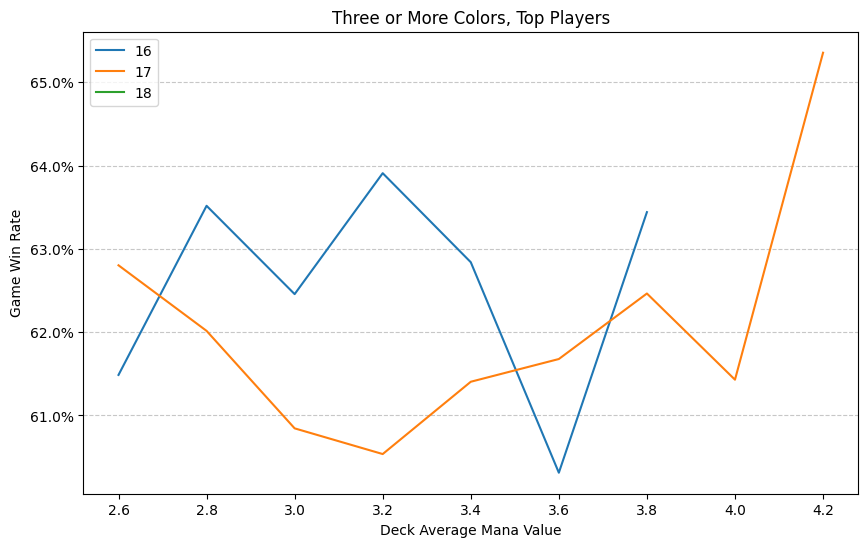

In [28]:
line_plot(
    pivot, 
    title="Three or More Colors, Top Players",
    is_pct=True,
    y_label="Game Win Rate"
)

In [2]:
wr_df=summon(
    ["DFT", "FDN", "PIO", 
     "BLB", "OTJ", "DSK", "MH3",
    "MKM", "KTK", "LCI", "LTR", "WOE"
    ], ["game_wr"], group_by=["game_hour"],
      filter_spec={"player_cohort":"Top"} )



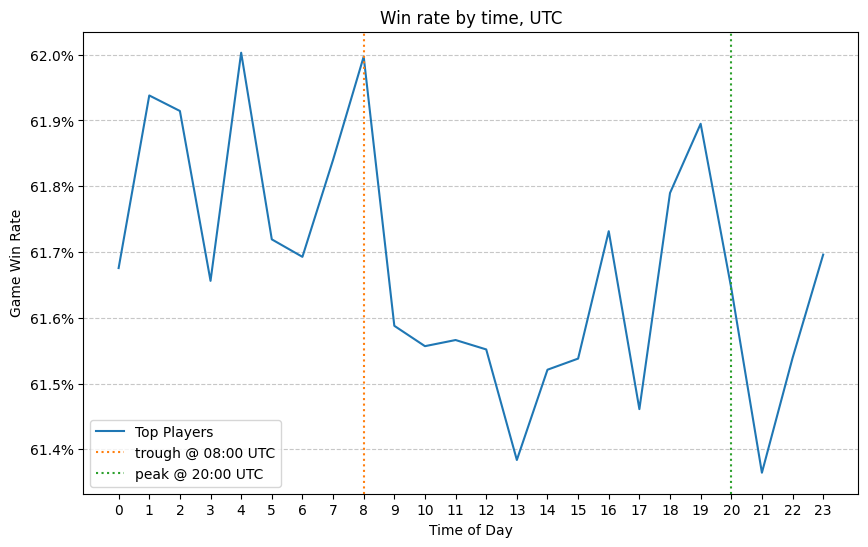

In [6]:
ax = line_plot(wr_df.rename({'game_wr': 'Top Players', 'game_hour': 'Time of Day'}), 
          title="Win rate by time, UTC",
          is_pct=True, 
          y_label="Game Win Rate",
          return_ax=True
    )


ax.axvline(x =8, color="#ff7f0e", linestyle=":", label="trough @ 08:00 UTC")
ax.axvline(x = 20, color="#2ca02c", linestyle=":", label="peak @ 20:00 UTC")
ax.legend()



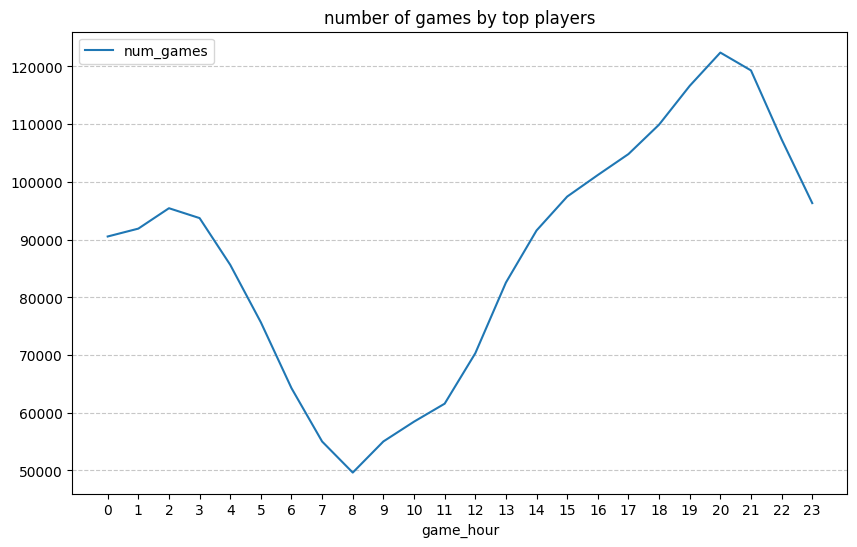

In [7]:
df=summon(
    ["DFT", "FDN", "PIO", 
     "BLB", "OTJ", "DSK", "MH3",
    "MKM", "KTK", "LCI", "LTR", "WOE"
    ], ["num_games"], group_by=["game_hour"],
      filter_spec={"player_cohort":"Top"} )
line_plot(df, title="number of games by top players")


In [49]:
summon(all_sets, ["deck_mana_value_avg"], group_by=[], filter_spec={'player_cohort':'Top'})

deck_mana_value_avg
f64
2.912826


In [17]:
from deq.mle import draft_equity
import polars as pl
from deq.plot import line_plot
import numpy as np

In [10]:
draft_equity('BLB', 1).pick_equity_df.select(['pick_num', -pl.col('remaining_pick_equity').diff()])

pick_num,remaining_pick_equity
i64,f64
0,null
1,0.009399
2,0.002747
3,0.000437
4,-0.001093
…,…
9,-0.005435
10,-0.006113
11,-0.006621


In [97]:
sets = ["MKM", "OTJ", "MH3", "BLB", "DSK", "FDN", "DFT"]
pick_equity_col = -pl.col('remaining_pick_equity').diff().alias('pick_equity_raw')
x = np.arange(1,15, dtype=np.int64)
df = pl.DataFrame({'pick_num': x})
for set_ in sets:
    df = df.join(draft_equity(set_, 1).pick_equity_df.select('pick_num', pick_equity_col).filter(pl.col('pick_num') > 0).rename({'pick_equity_raw': set_}), on = "pick_num", how="left")

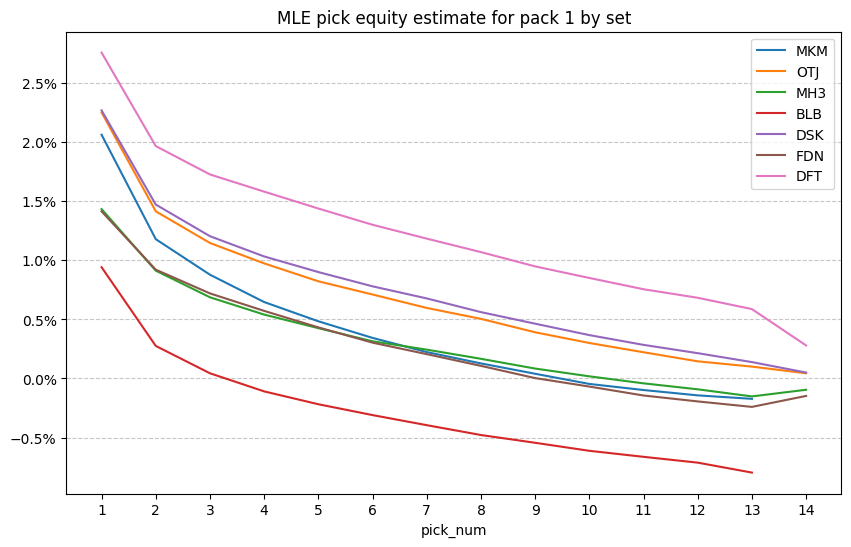

In [66]:
line_plot(df, title = "MLE pick equity estimate for pack 1 by set", is_pct=True)

In [99]:
    null_cards = draft_equity(set_, 1).df.filter(pl.col('q') <= 0).select('name')['name'].to_list()
    set_df = draft_equity(set_, 1, null_cards=null_cards).pick_equity_df.select('pick_num', pick_equity_col).filter(pl.col('pick_num') > 0)
    norm_val = set_df['pick_equity_raw'][13]
norm_val

0.005099699897566909

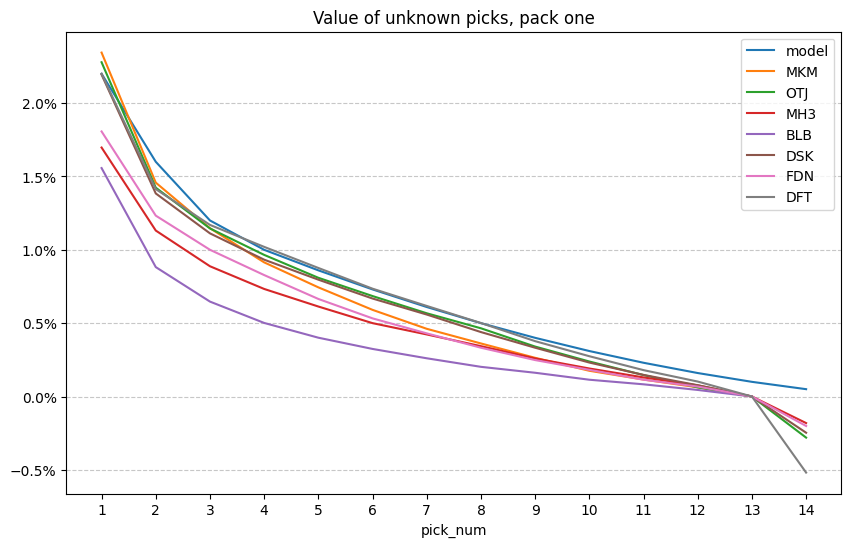

In [170]:
df = pl.DataFrame({'pick_num': x, 'model': y})
for set_ in sets:
    null_cards = draft_equity(set_, 1).df.filter(pl.col('q') <= 0).select('name')['name'].to_list()
    set_df = draft_equity(set_, 1, null_cards=null_cards).pick_equity_df.select('pick_num', pick_equity_col).filter(pl.col('pick_num') > 0)
    norm_val = set_df['pick_equity_raw'][12]
    df = df.join(set_df.select('pick_num', (pl.col('pick_equity_raw') - pl.lit(norm_val)).alias(set_)), on = "pick_num", how="left")

line_plot(df, is_pct=True, title="Value of unknown picks, pack one")

In [145]:
df['DSK']
a = np.array([0, .0006, .0013, .0021, .0030, .0040, .0051, .0062, .0074, .0087, .0101, .0125, .016, .022])
b = [a[13-i] for i in range(14)]

In [167]:
b = [0.022, 0.016, 0.012, 0.01, 0.0086, 0.0073, 0.0061, 0.005, 0.004, 0.0031, 0.0023, 0.0016, 0.0010, 0.0005]
np.polyfit(x[0:4], b[0:4], 2)

array([ 0.001, -0.009,  0.03 ])

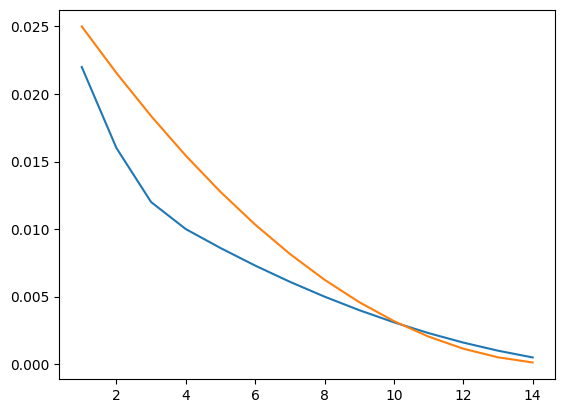

In [169]:
y = np.zeros(14)
y[0:4] = .001 * x[0:4] ** 2 - 0.009 * x[0:4] + 0.03
y[4:] = .00005 * x[4:] ** 2 - 0.00185 * x[4:] + 0.0166
plt.plot(x, y)
plt.plot(x, 0.025 * (1 - (x - 1)/14)**2)



In [95]:
pl.Config.set_tbl_rows(400)

polars.config.Config

In [96]:
result.df

name,q
str,f64
"""Sylvan Tutor""",0.041605
"""Valley Questcaller""",0.040922
"""Ygra, Eater of All""",0.040143
"""Dragonhawk, Fate's Tempest""",0.037207
"""Camellia, the Seedmiser""",0.034507
"""Season of Loss""",0.033475
"""Kitsa, Otterball Elite""",0.032523
"""Valley Mightcaller""",0.030688
"""Season of Gathering""",0.029024


In [196]:
from spells import summon, ColSpec, ColType
from spells.extension import stat_cols

ext = {
    'wins_per_event': ColSpec(
        col_type= ColType.AGG,
        expr= pl.col('num_won') / pl.col('num_events')
    ),
    'wins_per_event_mean': ColSpec(
        col_type= ColType.AGG,
        expr= pl.col('wins_per_event').mean()
    ),
    "wins_per_event_var": ColSpec(
            col_type=ColType.AGG,
            expr=(pl.col(f"{attr}_dw_excess").pow(2) * pl.col(ColName.DECK)).sum()
            / pl.col(ColName.DECK_TOTAL),
        ),
}

ext = {
    **ext,
    **stat_cols('wins_per_event')
}

summon('DFT', ['wins_per_event', 'num_events', 'wins_per_event_var'], group_by=["main_colors"], extensions=ext).filter

KeyError: 'wins_per_event_var'

In [235]:
def trophy_rate(mu):
    return 28 * mu ** 9 - 63 * mu ** 8 + 36 * mu ** 7

def trophy_rate_w_vol(mu, vol):
    return trophy_rate(mu) + 0.5 * trophy_conv(mu) * vol ** 2

def trophy_conv(mu):
    return 9 * 8 * 28 * mu ** 7 - 8 * 7 * 63 * mu ** 6 + 7 * 6 * 36 * mu ** 5

def deck_param_vol(sample_trophy_rate, mu):
    return np.sqrt(2 * (sample_trophy_rate - trophy_rate(mu)) / trophy_conv(mu))

mu = 0.55
base_vol = 0.02
print(f"Trophy rate for consistent {100 * mu:.0f}% deck")
print(trophy_rate(mu))
for i in range(1, 6):
    vol = base_vol * i
    print(f"Trophy rate with deck param vol {100 * vol:.0f}%")
    print(trophy_rate_w_vol(mu, vol))

Trophy rate for consistent 55% deck
0.1495031400156251
Trophy rate with deck param vol 2%
0.15132945835562508
Trophy rate with deck param vol 4%
0.1568084133756251
Trophy rate with deck param vol 6%
0.1659400050756251
Trophy rate with deck param vol 8%
0.1787242334556251
Trophy rate with deck param vol 10%
0.1951610985156251


In [229]:
from spells import summon

df = summon("DFT", ["trophy_rate", "picked_match_wr"], group_by=["expansion"])
mu = df['picked_match_wr'][0]
sample_trophy_rate = df['trophy_rate'][0]

print(f"Vol given mu = {100 * mu:.1f}%, trophy_rate = {100 * sample_trophy_rate:.2f}%") 
print(deck_param_vol(sample_trophy_rate, mu))
print("Oops!")

Vol given mu = 55.0%, trophy_rate = 9.29%
nan
Oops!


/tmp/ipykernel_150258/2029085386.py:11: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(2 * (sample_trophy_rate - trophy_rate(mu)) / trophy_conv(mu))
